Setting up the notebook

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

import pathlib
import shutil
import tempfile

from IPython import display
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [3]:
# current working directory
import os
print(os.getcwd())

/content


In [4]:
import os

# Specify the new working directory path
new_working_directory = '/content/drive/My Drive/A1/data-1'

# Change the working directory
os.chdir(new_working_directory)

In [5]:
import os
print(os.getcwd())

/content/drive/My Drive/A1/data-1


In [6]:
import os
uploaded_files = os.listdir()
uploaded_files

['A1.ipynb',
 'data_labels.csv',
 'CK+ AgreementForm.pdf',
 'cohn-kanade-images',
 'final.csv',
 'Copy of A1.ipynb',
 'test_image_negative.png',
 'test_images']

## Images Loading

The list_folders_and_images function takes a folder_path as input and initializes two empty lists: folders and image_files.

Within the function's bounds, a recursive function named explore_directory navigates the listed folder path's subdirectories.

For each entry in the directory, the function conducts a folder or image file check. Recursively calling the explore_directory function on a folder if it is a folder, adding its folder path to the list of folders. For image files (.png) only, the file path is added to the image_files list after processing.

Following the directory's explication, the function presents the list of folders and image files. Eventually, it provides the image_files list.

Subsequent to calling the list_folders_and_images function with the specified folder path, the returned list of image files is assigned to the image_files variable.

In [7]:
import os
import numpy as np
import pandas as pd
from PIL import Image  # Import Image from the PIL library

def list_folders_and_images(folder_path):
    folders = []
    image_files = []

    # Recursive function to explore subdirectories
    def explore_directory(directory):
        for item in os.listdir(directory):
            item_path = os.path.join(directory, item)
            if os.path.isdir(item_path):
                folders.append(item_path)
                explore_directory(item_path)
            elif item.endswith('.png'):
                image_files.append(item_path)

    explore_directory(folder_path)

    print("Folders:")
    for folder in folders:
        print(folder)

    print("\nImage Files:")
    for image_file in image_files:
        print(image_file)

    return image_files  # Return the list of image files


 # Return the list of image files
folder_path = './cohn-kanade-images'
image_files = list_folders_and_images(folder_path)
image_files

Streaming output truncated to the last 5000 lines.
./cohn-kanade-images/S114/001/S114_001_00000011.png
./cohn-kanade-images/S114/001/S114_001_00000016.png
./cohn-kanade-images/S114/001/S114_001_00000007.png
./cohn-kanade-images/S114/001/S114_001_00000004.png
./cohn-kanade-images/S114/001/S114_001_00000001.png
./cohn-kanade-images/S114/006/S114_006_00000001.png
./cohn-kanade-images/S114/006/S114_006_00000005.png
./cohn-kanade-images/S114/006/S114_006_00000002.png
./cohn-kanade-images/S114/006/S114_006_00000006.png
./cohn-kanade-images/S114/006/S114_006_00000004.png
./cohn-kanade-images/S114/006/S114_006_00000003.png
./cohn-kanade-images/S114/006/S114_006_00000011.png
./cohn-kanade-images/S114/006/S114_006_00000023.png
./cohn-kanade-images/S114/006/S114_006_00000015.png
./cohn-kanade-images/S114/006/S114_006_00000018.png
./cohn-kanade-images/S114/006/S114_006_00000020.png
./cohn-kanade-images/S114/006/S114_006_00000013.png
./cohn-kanade-images/S114/006/S114_006_00000007.png
./cohn-kanade

['./cohn-kanade-images/S129/012/S129_012_00000009.png',
 './cohn-kanade-images/S129/012/S129_012_00000003.png',
 './cohn-kanade-images/S129/012/S129_012_00000008.png',
 './cohn-kanade-images/S129/012/S129_012_00000005.png',
 './cohn-kanade-images/S129/012/S129_012_00000007.png',
 './cohn-kanade-images/S129/012/S129_012_00000006.png',
 './cohn-kanade-images/S129/012/S129_012_00000011.png',
 './cohn-kanade-images/S129/012/S129_012_00000001.png',
 './cohn-kanade-images/S129/012/S129_012_00000002.png',
 './cohn-kanade-images/S129/012/S129_012_00000010.png',
 './cohn-kanade-images/S129/012/S129_012_00000004.png',
 './cohn-kanade-images/S129/007/S129_007_00000004.png',
 './cohn-kanade-images/S129/007/S129_007_00000001.png',
 './cohn-kanade-images/S129/007/S129_007_00000003.png',
 './cohn-kanade-images/S129/007/S129_007_00000002.png',
 './cohn-kanade-images/S129/001/S129_001_00000009.png',
 './cohn-kanade-images/S129/001/S129_001_00000001.png',
 './cohn-kanade-images/S129/001/S129_001_0000000

Essentially, the code proves how images can be loaded and exploited for development purposes. Using the PIL library, it opens and resizes images while checking for and handling potential duplicate file paths within the DataFrame based on the 'filepath' column. Ensuring that each image is counted just once, the data frame is accurate. Next, the image data was transformed into NumPy arrays and merged with a Pandas DataFrame. This method facilitates streamlined image data management and manipulation, indispensable for flawless CNN model training and implementation.

In [8]:
import pandas as pd
import numpy as np
from PIL import Image
import os

# Function to load and convert images to NumPy arrays
def load_images(image_files):
    images = []
    for image_file in image_files:
        img = Image.open(image_file)
        # Resize the image to the desired dimensions (224x224)
        img = img.resize((224, 224))
        img_array = np.array(img)
        images.append(img_array)
    return images

# Load image files
folder_path = './cohn-kanade-images'
image_files = list_folders_and_images(folder_path)

# Load datalabels.csv into a Pandas DataFrame
df = pd.read_csv('data_labels.csv')

# Check for and handle potential duplicate file paths
df = df.drop_duplicates(subset='filepath', keep='first')

# Merge image data with the DataFrame based on the 'filepath' column
df['image_data'] = load_images(df['filepath'].tolist())

# Convert the 'image_data' column to a NumPy array
df['image_data'] = np.array(df['image_data'])



Streaming output truncated to the last 5000 lines.
./cohn-kanade-images/S114/001/S114_001_00000011.png
./cohn-kanade-images/S114/001/S114_001_00000016.png
./cohn-kanade-images/S114/001/S114_001_00000007.png
./cohn-kanade-images/S114/001/S114_001_00000004.png
./cohn-kanade-images/S114/001/S114_001_00000001.png
./cohn-kanade-images/S114/006/S114_006_00000001.png
./cohn-kanade-images/S114/006/S114_006_00000005.png
./cohn-kanade-images/S114/006/S114_006_00000002.png
./cohn-kanade-images/S114/006/S114_006_00000006.png
./cohn-kanade-images/S114/006/S114_006_00000004.png
./cohn-kanade-images/S114/006/S114_006_00000003.png
./cohn-kanade-images/S114/006/S114_006_00000011.png
./cohn-kanade-images/S114/006/S114_006_00000023.png
./cohn-kanade-images/S114/006/S114_006_00000015.png
./cohn-kanade-images/S114/006/S114_006_00000018.png
./cohn-kanade-images/S114/006/S114_006_00000020.png
./cohn-kanade-images/S114/006/S114_006_00000013.png
./cohn-kanade-images/S114/006/S114_006_00000007.png
./cohn-kanade

In [9]:
df.head()

,subject,sequence,image_index,filepath,file_prefix,AU17,AU1,AU2,AU25,AU27,...,AU23,AU24,AU6,AU12,AU15,AU14,AU11,AU26,high_level_emotion,image_data
0,S005,1,11,./cohn-kanade-images/S005/001/S005_001_0000001...,S005_001_00000011,1,0,0,0,0,...,0,0,0,0,0,0,0,0,negative,"[[46, 159, 203, 109, 7, 54, 182, 214, 214, 214..."
1,S010,1,14,./cohn-kanade-images/S010/001/S010_001_0000001...,S010_001_00000014,0,1,1,1,0,...,0,0,0,0,0,0,0,0,negative,"[[50, 171, 200, 108, 22, 7, 1, 19, 133, 207, 2..."
2,S010,2,14,./cohn-kanade-images/S010/002/S010_002_0000001...,S010_002_00000014,0,1,1,1,1,...,0,0,0,0,0,0,0,0,surprise,"[[32, 142, 207, 125, 19, 0, 1, 3, 107, 206, 16..."
3,S010,3,18,./cohn-kanade-images/S010/003/S010_003_0000001...,S010_003_00000018,1,0,0,0,0,...,0,0,0,0,0,0,0,0,negative,"[[39, 155, 205, 120, 21, 1, 2, 0, 1, 0, 59, 18..."
4,S010,4,19,./cohn-kanade-images/S010/004/S010_004_0000001...,S010_004_00000019,1,0,0,0,0,...,1,1,0,0,0,0,0,0,negative,"[[45, 157, 199, 107, 9, 56, 175, 214, 215, 214..."


In [10]:
df.dtypes

subject               object
sequence               int64
image_index            int64
filepath              object
file_prefix           object
AU17                   int64
AU1                    int64
AU2                    int64
AU25                   int64
AU27                   int64
AU4                    int64
AU7                    int64
AU23                   int64
AU24                   int64
AU6                    int64
AU12                   int64
AU15                   int64
AU14                   int64
AU11                   int64
AU26                   int64
high_level_emotion    object
image_data            object
dtype: object

In [11]:
# Checking the data type
first_image_array = df['image_data'][0]
print(type(first_image_array))

<class 'numpy.ndarray'>


# Converting grayscale to RGB
The function convert_grayscale_to_rgb consumes an image as input and changes it from grayscale to RGB structure. If the number of dimensions equals 2, an image is categorized as grayscale and 3 as RGB.

The np.stack function, from the NumPy library, enables the conversion process of grayscale images to RGB. Stacked three times along the last axis, the grayscale image array transforms into an array with three channels (red, green, and blue) using the np.stack function. The conversion process transforms the grayscale image into RGB format.

In the 'image_data' column of a Pandas DataFrame referred to as df, it applies the necessary conversion through the use of convert_grayscale_to_rgb. the 'image_data' column is converted to RGB numpy arrays.

With CNN models, having RGB images instead of grayscale ones is particularly helpful since CNNs usually expect RGB input images, the model I'm training is MobileNetV2 . With the addition of RGB, CNN models gain a richer comprehension of the aesthetic nuances like colour and texture increasing performance and accuracy.

In [12]:
import numpy as np

# Checking the image types and count
image_count = len(df['image_data'])
gray_count = 0
rgb_count = 0

for image in df['image_data']:
    if len(image.shape) == 2:
        gray_count += 1
    elif len(image.shape) == 3 and image.shape[2] == 3:
        rgb_count += 1

print(f"Total Images: {image_count}")
print(f"Gray Images: {gray_count}")
print(f"RGB Images: {rgb_count}")


Total Images: 560
Gray Images: 521
RGB Images: 39


In [13]:
import numpy as np
import pandas as pd

# Function to convert grayscale image to RGB
def convert_grayscale_to_rgb(image):
    # Check if the image is grayscale
    if len(image.shape) == 2:
        # Convert grayscale image to RGB
        image = np.stack((image,) * 3, axis=-1)
    return image

# Convert grayscale images to RGB in the image_data column
df['image_data'] = df['image_data'].apply(convert_grayscale_to_rgb)


In [14]:
import numpy as np

# Checking the image types and count
image_count = len(df['image_data'])
gray_count = 0
rgb_count = 0

for image in df['image_data']:
    if len(image.shape) == 2:
        gray_count += 1
    elif len(image.shape) == 3 and image.shape[2] == 3:
        rgb_count += 1

print(f"Total Images: {image_count}")
print(f"Gray Images: {gray_count}")
print(f"RGB Images: {rgb_count}")


Total Images: 560
Gray Images: 0
RGB Images: 560


In [15]:
import random
# Double checking the image sizes to fit the model.
# Choose a random row from your DataFrame
random_row = random.randint(0, len(df) - 1)

# Access the 'image_data' column of the random row and check its shape
random_image = df['image_data'].iloc[random_row]
image_height, image_width, channels = random_image.shape

print(f"Random Image Dimensions - Height: {image_height}, Width: {image_width}, Channels: {channels}")


Random Image Dimensions - Height: 224, Width: 224, Channels: 3


In [16]:
df.head(5)

,subject,sequence,image_index,filepath,file_prefix,AU17,AU1,AU2,AU25,AU27,...,AU23,AU24,AU6,AU12,AU15,AU14,AU11,AU26,high_level_emotion,image_data
0,S005,1,11,./cohn-kanade-images/S005/001/S005_001_0000001...,S005_001_00000011,1,0,0,0,0,...,0,0,0,0,0,0,0,0,negative,"[[[46, 46, 46], [159, 159, 159], [203, 203, 20..."
1,S010,1,14,./cohn-kanade-images/S010/001/S010_001_0000001...,S010_001_00000014,0,1,1,1,0,...,0,0,0,0,0,0,0,0,negative,"[[[50, 50, 50], [171, 171, 171], [200, 200, 20..."
2,S010,2,14,./cohn-kanade-images/S010/002/S010_002_0000001...,S010_002_00000014,0,1,1,1,1,...,0,0,0,0,0,0,0,0,surprise,"[[[32, 32, 32], [142, 142, 142], [207, 207, 20..."
3,S010,3,18,./cohn-kanade-images/S010/003/S010_003_0000001...,S010_003_00000018,1,0,0,0,0,...,0,0,0,0,0,0,0,0,negative,"[[[39, 39, 39], [155, 155, 155], [205, 205, 20..."
4,S010,4,19,./cohn-kanade-images/S010/004/S010_004_0000001...,S010_004_00000019,1,0,0,0,0,...,1,1,0,0,0,0,0,0,negative,"[[[45, 45, 45], [157, 157, 157], [199, 199, 19..."


In [17]:
# checking the class distribution - we have a imbalanced dataset.
df['high_level_emotion'].value_counts()

negative    328
positive    121
surprise    111
Name: high_level_emotion, dtype: int64

# Data Augmentation

 Essential for enhancing model adaptability, data augmentation plays a significant role. In your code, you are applying several data augmentation techniques to the training images:
* **rotation_range=15:** Rotate the images randomly between 0 and 15 degrees. By improving its orientation resistance, the model now aligns with real-world samples better.
* **horizontal_flip=True:** Randomly flip images horizontally. Expanding the range of training data enables the model to develop diversity.
* **vertical_flip=True:** Vertical image flipping adds variety to the training data for increased diversity.
* **zoom_range=0.2:** Experiment with varied image magnifications between 0% and 20%. With scaling variations, the model advances in object recognition.
* **brightness_range=[0.8, 1]:** Alters the image's luminosity. Managing these variations enables the model to adapt to various lighting environments.  
* **rescale=1./255:** Normalizing pixel values within the restrictive range of [0, 1] helps secure steady training.
* **channel_shift_range=0.3:** Randomly shift the colour channels, merely saturate. This approach bolsters the model's endurance against vibrant changes in the data.
* **fill_mode='nearest':** Near the border, refine pixels using the nearest neighbour method. Transformations can occur with security-preserving image structure.
Designating a batch size of 32 for both data generators - training and testing/validation. Smaller batch sizes accelerate training, and MobileNetV2's design enables optimal performance with these reduced batch sizes, thus fostering efficiency on mobile and limited-resource platforms.
* **Class Mode:** To accommodate multi-class classification, where each image may belong to multiple categories, you set the class mode to "categorical."

* **Target Size:** Scaling them down to a target size of (224, 224), the images are adjusted. The input size employed by MobileNetV2 and other pre-trained models is well-established. Streamlining the input size enables seamless integration with pre-trained models and promotes compatibility across various models.

Data Generators:

ImageDataGenerator helps with generating required data sets for model development, evaluation, and validation. While training and testing models, generators will develop batches of augmented images.

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2

# Split the data into training, testing, and validation sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

# Perform data augmentation on the training set
train_datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1],  # Randomly adjust brightness (80-120%)
    rescale=1./255,  # Normalize pixel values to [0, 1]
    channel_shift_range=0.3,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='high_level_emotion',
    batch_size=32,
    class_mode='categorical',
    target_size=(224, 224)
)

# Define the testing and validation generators
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='high_level_emotion',
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='high_level_emotion',
    batch_size=32,
    class_mode='categorical'
)

print(train_df.shape)
print(test_df.shape)
print(val_df.shape)


Found 358 validated image filenames belonging to 3 classes.
Found 112 validated image filenames belonging to 3 classes.
Found 90 validated image filenames belonging to 3 classes.
(358, 22)
(112, 22)
(90, 22)


Displaying 10 augmented images, our model will be trained with a batch of augmented images.

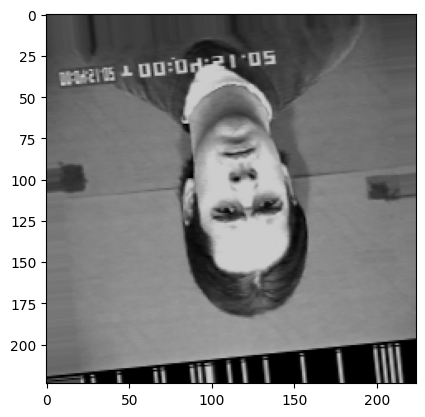

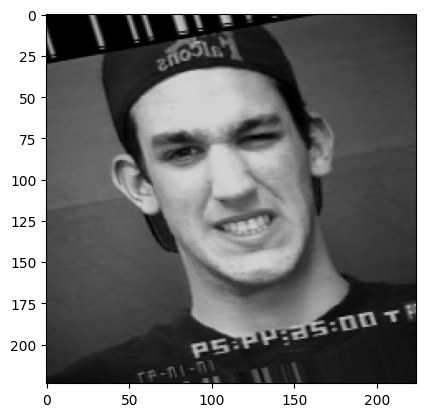

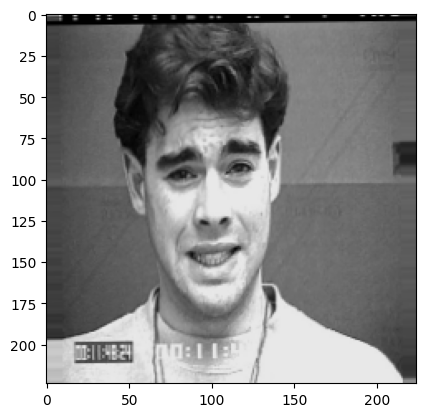

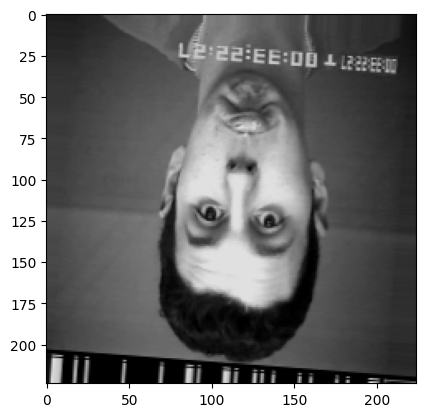

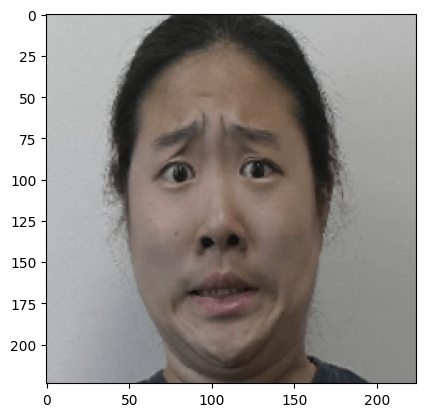

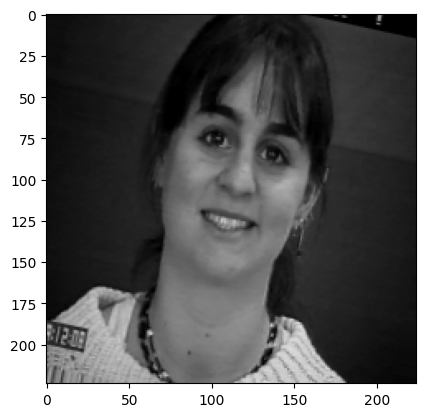

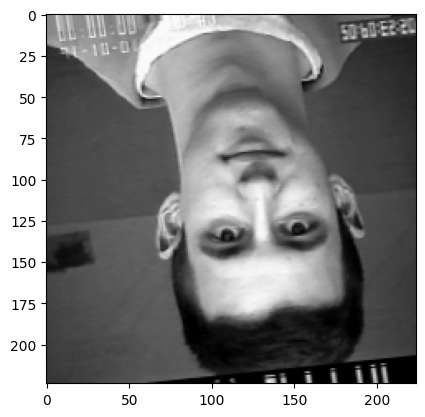

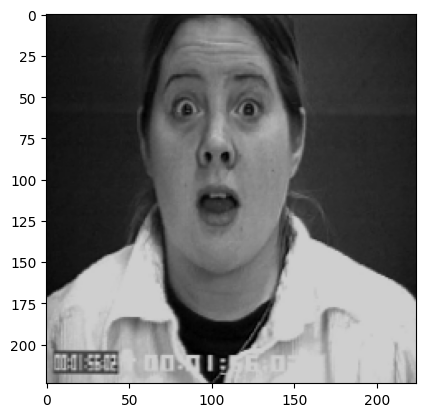

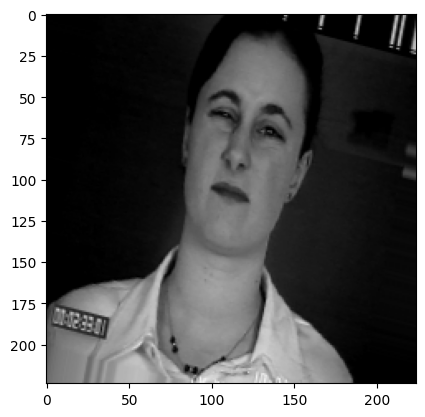

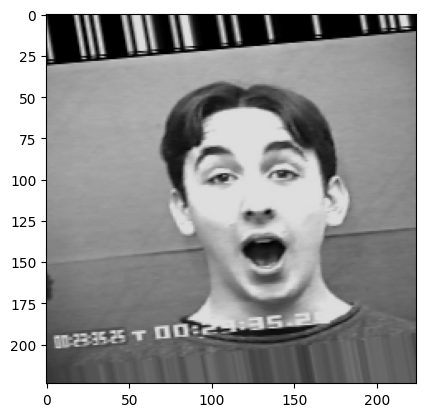

In [19]:
augmented_images = train_generator.next()
for i in range(10):
    image = augmented_images[0][i]
    # Display or save the augmented image as per your requirement
    plt.imshow(image)
    plt.show()

In [20]:
# Checking the values of emotion classes in each df
print("Training Set\n", train_df['high_level_emotion'].value_counts(), train_df.shape )
print("Testing Set\n",test_df['high_level_emotion'].value_counts(), test_df.shape)
print("Validation Set\n",val_df['high_level_emotion'].value_counts(), val_df.shape)


Training Set
 negative    202
positive     81
surprise     75
Name: high_level_emotion, dtype: int64 (358, 22)
Testing Set
 negative    75
surprise    19
positive    18
Name: high_level_emotion, dtype: int64 (112, 22)
Validation Set
 negative    51
positive    22
surprise    17
Name: high_level_emotion, dtype: int64 (90, 22)


In [21]:
# one-hot encoding 'high_level_emotion' column and converting it to float to feed into the algorithm
train_df['high_level_emotion'] = train_df['high_level_emotion'].replace({'positive': 0, 'negative': 1, 'surprise': 2})
test_df['high_level_emotion'] = test_df['high_level_emotion'].replace({'positive': 0, 'negative': 1, 'surprise': 2})
val_df['high_level_emotion'] = val_df['high_level_emotion'].replace({'positive': 0, 'negative': 1, 'surprise': 2})
train_df['high_level_emotion'] = train_df['high_level_emotion'].astype(float)
test_df['high_level_emotion'] = test_df['high_level_emotion'].astype(float)
val_df['high_level_emotion'] = val_df['high_level_emotion'].astype(float)
train_df.head()
# Print the updated DataFrame

,subject,sequence,image_index,filepath,file_prefix,AU17,AU1,AU2,AU25,AU27,...,AU23,AU24,AU6,AU12,AU15,AU14,AU11,AU26,high_level_emotion,image_data
497,S133,4,15,./cohn-kanade-images/S133/004/S133_004_0000001...,S133_004_00000015,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1.0,"[[[94, 94, 94], [170, 170, 170], [109, 109, 10..."
268,S091,1,15,./cohn-kanade-images/S091/001/S091_001_0000001...,S091_001_00000015,0,1,1,1,0,...,0,0,0,0,0,0,0,0,1.0,"[[[120, 120, 120], [186, 186, 186], [113, 113,..."
36,S032,5,16,./cohn-kanade-images/S032/005/S032_005_0000001...,S032_005_00000016,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1.0,"[[[67, 67, 67], [173, 173, 173], [193, 193, 19..."
370,S111,4,10,./cohn-kanade-images/S111/004/S111_004_0000001...,S111_004_00000010,0,0,0,1,0,...,0,0,0,0,0,0,0,0,2.0,"[[[111, 111, 111], [176, 176, 176], [112, 112,..."
468,S129,11,18,./cohn-kanade-images/S129/011/S129_011_0000001...,S129_011_00000018,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1.0,"[[[84, 84, 84], [158, 158, 158], [111, 111, 11..."


In [22]:
first_image_array = train_df['image_data'][0]
high_level_emotion = train_df['high_level_emotion'][0]
print(type(first_image_array))
print(type(high_level_emotion))

<class 'numpy.ndarray'>
<class 'numpy.float64'>


## Upsampling the minority emotion classes

Imbalanced datasets can lead to model bias, where the model may have difficulty learning the minority classes effectively. By up sampling the minority classes, I tried to create a more balanced dataset, ensuring that the model gets exposed to a similar number of examples from each class during training potentially leading to better classification performance on the minority classes. Up sampling provides more training data for the minority classes, reducing the risk of overfitting and improving the model's ability to generalize.

In [23]:
import pandas as pd
from sklearn.utils import resample

# Define the class labels and corresponding float values
class_labels = {'positive': 0.0, 'negative': 1.0, 'surprise': 2.0}

# Separate the classes based on the float values
negative = train_df[train_df['high_level_emotion'] == class_labels['negative']]
positive = train_df[train_df['high_level_emotion'] == class_labels['positive']]
surprise = train_df[train_df['high_level_emotion'] == class_labels['surprise']]

# Calculate the number of samples in the majority class (e.g., 'negative')
majority_class_samples = len(negative)

# Upsample the minority classes to match the number of samples in the majority class
positive_upsampled = resample(positive,
                              replace=True,
                              n_samples=majority_class_samples,
                              random_state=42)
surprise_upsampled = resample(surprise,
                              replace=True,
                              n_samples=majority_class_samples,
                              random_state=42)

# Combine the upsampled classes with the majority class
balanced_train_df = pd.concat([negative, positive_upsampled, surprise_upsampled])

# Shuffle the dataset
train_df = balanced_train_df.sample(frac=1, random_state=42)
train_df['high_level_emotion'].value_counts()


2.0    202
0.0    202
1.0    202
Name: high_level_emotion, dtype: int64

In [25]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

def preprocess_image(image):
    image = tf.image.resize(image, (224, 224))
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image

train_generator = np.array([preprocess_image(image) for image in train_df['image_data']])
val_generator = np.array([preprocess_image(image) for image in val_df['image_data']])
test_generator = np.array([preprocess_image(image) for image in test_df['image_data']])

train_labels_emotion = np.array(train_df['high_level_emotion'])
val_labels_emotion = np.array(val_df['high_level_emotion'])
test_labels_emotion = np.array(test_df['high_level_emotion'])

train_labels_facs = np.array(train_df[['AU17', 'AU1', 'AU2', 'AU25', 'AU27', 'AU4', 'AU7', 'AU23', 'AU24', 'AU6', 'AU12', 'AU15', 'AU14', 'AU11', 'AU26']])
val_labels_facs = np.array(val_df[['AU17', 'AU1', 'AU2', 'AU25', 'AU27', 'AU4', 'AU7', 'AU23', 'AU24', 'AU6', 'AU12', 'AU15', 'AU14', 'AU11', 'AU26']])
test_labels_facs = np.array(test_df[['AU17', 'AU1', 'AU2', 'AU25', 'AU27', 'AU4', 'AU7', 'AU23', 'AU24', 'AU6', 'AU12', 'AU15', 'AU14', 'AU11', 'AU26']])

# Define the CNN architecture using a pre-trained MobileNetV2 base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
# Add custom layers on top of the MobileNetV2 base
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(64, activation='relu')(x)
emotion_output = layers.Dense(3, activation='softmax', name='emotion_output')(x)  # 3 classes for high-level emotion prediction
facs_output = layers.Dense(15, activation='sigmoid', name='facs_output')(x)  # 15 classes for FACs prediction

# Create the model
model1 = models.Model(inputs=base_model.input, outputs=[emotion_output, facs_output])

# Compile the model
model1.compile(optimizer='adam',
              loss={'emotion_output': 'sparse_categorical_crossentropy', 'facs_output': 'binary_crossentropy'},
              metrics={'emotion_output': ['accuracy'], 'facs_output': ['accuracy']})

# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = model1.fit(train_generator,
                    {'emotion_output': train_labels_emotion, 'facs_output': train_labels_facs},
                    validation_data=(val_generator, {'emotion_output': val_labels_emotion, 'facs_output': val_labels_facs}),
                    epochs=10, batch_size=32, shuffle=True,
                    callbacks=[early_stopping])




Epoch 1/10
19/19 [==============================] - 30s 1s/step - loss: 1.7017 - emotion_output_loss: 1.1531 - facs_output_loss: 0.5486 - emotion_output_accuracy: 0.4026 - facs_output_accuracy: 0.1601 - val_loss: 1.5733 - val_emotion_output_loss: 1.0964 - val_facs_output_loss: 0.4769 - val_emotion_output_accuracy: 0.3111 - val_facs_output_accuracy: 0.4000
Epoch 2/10
19/19 [==============================] - 29s 2s/step - loss: 1.3624 - emotion_output_loss: 0.9167 - facs_output_loss: 0.4457 - emotion_output_accuracy: 0.5479 - facs_output_accuracy: 0.3300 - val_loss: 1.5982 - val_emotion_output_loss: 1.1434 - val_facs_output_loss: 0.4548 - val_emotion_output_accuracy: 0.3556 - val_facs_output_accuracy: 0.4333
Epoch 3/10
19/19 [==============================] - 23s 1s/step - loss: 1.2695 - emotion_output_loss: 0.8406 - facs_output_loss: 0.4289 - emotion_output_accuracy: 0.5875 - facs_output_accuracy: 0.3300 - val_loss: 1.4918 - val_emotion_output_loss: 1.0457 - val_facs_output_loss: 0.4460

In [26]:
model1.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                           

In [27]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# After training, you can compute metrics on validation data
val_predictions = model1.predict(val_generator)
val_emotion_predictions = val_predictions[0]
val_facs_predictions = val_predictions[1]

# Compute classification metrics for emotion prediction
val_emotion_labels_pred = np.argmax(val_emotion_predictions, axis=1)
precision_emotion = precision_score(val_labels_emotion, val_emotion_labels_pred, average='macro', zero_division=1)
recall_emotion = recall_score(val_labels_emotion, val_emotion_labels_pred, average='macro', zero_division=1)
roc_auc_emotion = roc_auc_score(val_labels_emotion, val_emotion_predictions, average='macro', multi_class='ovr')

# Compute classification metrics for FACs prediction
precision_facs = precision_score(val_labels_facs, np.round(val_facs_predictions), average='micro', zero_division=1)
recall_facs = recall_score(val_labels_facs, np.round(val_facs_predictions), average='micro', zero_division=1)
roc_auc_facs = roc_auc_score(val_labels_facs, val_facs_predictions, average='micro')

# Print or use these metrics as needed
print("Validation Emotion Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(precision_emotion, recall_emotion, roc_auc_emotion))
print("Validation Facs Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(precision_facs, recall_facs, roc_auc_facs))


3/3 [==============================] - 5s 1s/step
Validation Emotion Metrics - Precision: 0.4894, Recall: 0.4504, ROC AUC: 0.5638
Validation Facs Metrics - Precision: 0.5510, Recall: 0.2085, ROC AUC: 0.7108


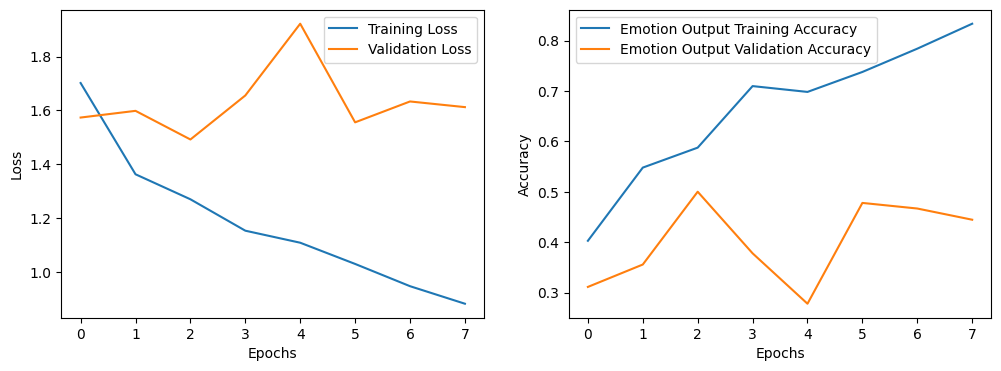

In [28]:
def plot_learning_curve(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['emotion_output_accuracy'], label='Emotion Output Training Accuracy')
    plt.plot(history.history['val_emotion_output_accuracy'], label='Emotion Output Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# Plot Learning Curve
plot_learning_curve(history)

In [29]:
test_predictions = model1.predict(test_generator)
test_emotion_predictions = test_predictions[0]
test_facs_predictions = test_predictions[1]

test_emotion_labels_pred = np.argmax(test_emotion_predictions, axis=1)
precision_emotion_test = precision_score(test_labels_emotion, test_emotion_labels_pred, average='macro',zero_division=1)
recall_emotion_test = recall_score(test_labels_emotion, test_emotion_labels_pred, average='macro',zero_division=1)
roc_auc_emotion_test = roc_auc_score(test_labels_emotion, test_emotion_predictions, average='macro', multi_class='ovr')

# Compute classification metrics for FACs prediction
precision_facs_test = precision_score(test_labels_facs, np.round(test_facs_predictions), average='micro',zero_division=1)
recall_facs_test = recall_score(test_labels_facs, np.round(test_facs_predictions), average='micro',zero_division=1)
roc_auc_facs_test = roc_auc_score(test_labels_facs, test_facs_predictions, average='micro')

# Print or use these metrics as needed
print("Testing Emotion Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(precision_emotion_test, recall_emotion_test, roc_auc_emotion_test))
print("Testing FACs Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(precision_facs_test, recall_facs_test, roc_auc_facs_test))


4/4 [==============================] - 3s 808ms/step
Testing Emotion Metrics - Precision: 0.5581, Recall: 0.4722, ROC AUC: 0.6690
Testing FACs Metrics - Precision: 0.4298, Recall: 0.1390, ROC AUC: 0.6462


Hyper-Parameter Tuning


In [30]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split, ParameterGrid
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Define variables to keep track of the best hyperparameters and corresponding metrics
best_hyperparameters_emotion = None
best_metrics_emotion = {'precision': 0.0, 'recall': 0.0, 'roc_auc': 0.0}
best_hyperparameters_facs = None
best_metrics_facs = {'precision': 0.0, 'recall': 0.0, 'roc_auc': 0.0}

# Define a function to create and compile the model with given hyperparameters
def create_model(learning_rate, dense_layer_units, dropout_rate):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.BatchNormalization()(x)  # Add BatchNormalization
    emotion_output = layers.Dense(3, activation='softmax', name='emotion_output')(x)
    facs_output = layers.Dense(15, activation='sigmoid', name='facs_output')(x)
    model2 = models.Model(inputs=base_model.input, outputs=[emotion_output, facs_output])
    model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),
                  loss={'emotion_output': 'sparse_categorical_crossentropy', 'facs_output': 'binary_crossentropy'},
                  metrics={'emotion_output': 'accuracy', 'facs_output': 'accuracy'})
    return model2

# Define the hyperparameter grid
param_grid = {
    'learning_rate': [0.0001, 0.001],
    'dense_layer_units': [32, 64],
    'dropout_rate': [0.3, 0.5],
}

# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Create lists to store results
results = []

# Iterate through hyperparameter combinations
for params in ParameterGrid(param_grid):
    print("Training model with hyperparameters:", params)

    # Create and compile the model with the current hyperparameters
    model2 = create_model(**params)

    # Train the model
    history = model2.fit(train_generator,
                        {'emotion_output': train_labels_emotion, 'facs_output': train_labels_facs},
                        validation_data=(val_generator, {'emotion_output': val_labels_emotion, 'facs_output': val_labels_facs}),
                        epochs=10, batch_size=32, shuffle=True,
                        callbacks=[early_stopping])



Training model with hyperparameters: {'dense_layer_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0001}
Epoch 1/10
19/19 [==============================] - 37s 2s/step - loss: 2.1552 - emotion_output_loss: 1.3437 - facs_output_loss: 0.8115 - emotion_output_accuracy: 0.3482 - facs_output_accuracy: 0.0561 - val_loss: 1.7639 - val_emotion_output_loss: 1.0886 - val_facs_output_loss: 0.6752 - val_emotion_output_accuracy: 0.5667 - val_facs_output_accuracy: 0.1667
Epoch 2/10
19/19 [==============================] - 23s 1s/step - loss: 1.9293 - emotion_output_loss: 1.1293 - facs_output_loss: 0.8000 - emotion_output_accuracy: 0.4290 - facs_output_accuracy: 0.0677 - val_loss: 1.6836 - val_emotion_output_loss: 1.0044 - val_facs_output_loss: 0.6792 - val_emotion_output_accuracy: 0.5444 - val_facs_output_accuracy: 0.1667
Epoch 3/10
19/19 [==============================] - 28s 2s/step - loss: 1.8089 - emotion_output_loss: 1.0141 - facs_output_loss: 0.7948 - emotion_output_accuracy: 0.5017 - fac

In [31]:
    # Store the results
    results.append({
        'hyperparameters': params,
        'emotion_metrics': {'precision': precision_emotion, 'recall': recall_emotion, 'roc_auc': roc_auc_emotion},
        'facs_metrics': {'precision': precision_facs, 'recall': recall_facs, 'roc_auc': roc_auc_facs}
    })

    # Check if this model has the best emotion prediction metrics
    if roc_auc_emotion > best_metrics_emotion['roc_auc']:
        best_metrics_emotion = {'precision': precision_emotion, 'recall': recall_emotion, 'roc_auc': roc_auc_emotion}
        best_hyperparameters_emotion = params

    # Check if this model has the best FACs prediction metrics
    if roc_auc_facs > best_metrics_facs['roc_auc']:
        best_metrics_facs = {'precision': precision_facs, 'recall': recall_facs, 'roc_auc': roc_auc_facs}
        best_hyperparameters_facs = params

# Print the best hyperparameters and corresponding metrics for both tasks
print("Best Hyperparameters for Emotion Prediction:")
print(best_hyperparameters_emotion)
print("Best Emotion Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(
    best_metrics_emotion['precision'], best_metrics_emotion['recall'], best_metrics_emotion['roc_auc']))

print("\nBest Hyperparameters for FACs Prediction:")
print(best_hyperparameters_facs)
print("Best FACs Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(
    best_metrics_facs['precision'], best_metrics_facs['recall'], best_metrics_facs['roc_auc']))

Best Hyperparameters for Emotion Prediction:
{'dense_layer_units': 64, 'dropout_rate': 0.5, 'learning_rate': 0.001}
Best Emotion Metrics - Precision: 0.4894, Recall: 0.4504, ROC AUC: 0.5638

Best Hyperparameters for FACs Prediction:
{'dense_layer_units': 64, 'dropout_rate': 0.5, 'learning_rate': 0.001}
Best FACs Metrics - Precision: 0.5510, Recall: 0.2085, ROC AUC: 0.7108


In [32]:
# After training, compute metrics on validation data
val_predictions = model2.predict(val_generator)
val_emotion_predictions = val_predictions[0]
val_facs_predictions = val_predictions[1]

# Compute classification metrics for emotion prediction
val_emotion_labels_pred = np.argmax(val_emotion_predictions, axis=1)
precision_emotion = precision_score(val_labels_emotion, val_emotion_labels_pred, average='macro')
recall_emotion = recall_score(val_labels_emotion, val_emotion_labels_pred, average='macro')
roc_auc_emotion = roc_auc_score(val_labels_emotion, val_emotion_predictions, average='macro', multi_class='ovr')

# Compute classification metrics for FACs prediction
precision_facs = precision_score(val_labels_facs, np.round(val_facs_predictions), average='micro')
recall_facs = recall_score(val_labels_facs, np.round(val_facs_predictions), average='micro')
roc_auc_facs = roc_auc_score(val_labels_facs, val_facs_predictions, average='micro')

# Print metrics
print("Validation Emotion Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(precision_emotion, recall_emotion, roc_auc_emotion))
print("Validation Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(precision_facs, recall_facs, roc_auc_facs))

3/3 [==============================] - 5s 1s/step
Validation Emotion Metrics - Precision: 0.5066, Recall: 0.4046, ROC AUC: 0.5948
Validation Metrics - Precision: 0.3298, Recall: 0.4865, ROC AUC: 0.6850


In [33]:
# After training, compute metrics on test data
test_predictions = model2.predict(test_generator)
test_emotion_predictions = test_predictions[0]
test_facs_predictions = test_predictions[1]

# Compute classification metrics for emotion prediction
test_emotion_labels_pred = np.argmax(test_emotion_predictions, axis=1)
precision_emotion = precision_score(test_labels_emotion, test_emotion_labels_pred, average='macro')
recall_emotion = recall_score(test_labels_emotion, test_emotion_labels_pred, average='macro')
roc_auc_emotion = roc_auc_score(test_labels_emotion, test_emotion_predictions, average='macro', multi_class='ovr')

# Compute classification metrics for FACs prediction
precision_facs = precision_score(test_labels_facs, np.round(test_facs_predictions), average='micro')
recall_facs = recall_score(test_labels_facs, np.round(test_facs_predictions), average='micro')
roc_auc_facs = roc_auc_score(test_labels_facs, test_facs_predictions, average='micro')

# Printing metrics
print("Test Emotion Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(precision_emotion, recall_emotion, roc_auc_emotion))
print("Test FACs Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(precision_facs, recall_facs, roc_auc_facs))


4/4 [==============================] - 5s 1s/step
Test Emotion Metrics - Precision: 0.6738, Recall: 0.5929, ROC AUC: 0.7107
Test FACs Metrics - Precision: 0.3408, Recall: 0.4492, ROC AUC: 0.6572


MODEL WITH THE BEST HYPER PARAMETERS

In [34]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

def preprocess_image(image):
    image = tf.image.resize(image, (224, 224))
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image

# Define the CNN architecture using a pre-trained MobileNetV2 base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
# Add custom layers on top of the MobileNetV2 base
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(64, activation='relu')(x)
x = layers.BatchNormalization()(x)  # Add BatchNormalization
x = layers.Dropout(0.5)(x)
emotion_output = layers.Dense(3, activation='softmax', name='emotion_output')(x)  # 3 classes for high-level emotion prediction
facs_output = layers.Dense(15, activation='sigmoid', name='facs_output')(x)  # 15 classes for FACs prediction

# Create the model
final_model = models.Model(inputs=base_model.input, outputs=[emotion_output, facs_output])

# Compile the model
base_learning_rate = 0.001
final_model.compile(optimizer=tf.keras.optimizers.Adam(lr=base_learning_rate),
              loss={'emotion_output': 'sparse_categorical_crossentropy', 'facs_output': 'binary_crossentropy'},
              metrics={'emotion_output': ['accuracy'], 'facs_output': 'accuracy'})

# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = final_model.fit(train_generator,
                    {'emotion_output': train_labels_emotion, 'facs_output': train_labels_facs},
                    validation_data=(val_generator, {'emotion_output': val_labels_emotion, 'facs_output': val_labels_facs}),
                    epochs=10, batch_size=32, shuffle=True,
                    callbacks=[early_stopping])




Epoch 1/10
19/19 [==============================] - 34s 2s/step - loss: 2.2225 - emotion_output_loss: 1.3577 - facs_output_loss: 0.8649 - emotion_output_accuracy: 0.4406 - facs_output_accuracy: 0.0743 - val_loss: 2.5324 - val_emotion_output_loss: 1.6709 - val_facs_output_loss: 0.8615 - val_emotion_output_accuracy: 0.3444 - val_facs_output_accuracy: 0.3889
Epoch 2/10
19/19 [==============================] - 36s 2s/step - loss: 1.7346 - emotion_output_loss: 0.9283 - facs_output_loss: 0.8063 - emotion_output_accuracy: 0.5941 - facs_output_accuracy: 0.0693 - val_loss: 2.0957 - val_emotion_output_loss: 1.2211 - val_facs_output_loss: 0.8747 - val_emotion_output_accuracy: 0.3444 - val_facs_output_accuracy: 0.3444
Epoch 3/10
19/19 [==============================] - 32s 2s/step - loss: 1.4665 - emotion_output_loss: 0.7056 - facs_output_loss: 0.7609 - emotion_output_accuracy: 0.6881 - facs_output_accuracy: 0.0858 - val_loss: 1.9879 - val_emotion_output_loss: 1.1874 - val_facs_output_loss: 0.8005

In [35]:
test_predictions = final_model.predict(test_generator)
test_emotion_predictions = test_predictions[0]
test_facs_predictions = test_predictions[1]

test_emotion_labels_pred = np.argmax(test_emotion_predictions, axis=1)
precision_emotion_test = precision_score(test_labels_emotion, test_emotion_labels_pred, average='macro',zero_division=1)
recall_emotion_test = recall_score(test_labels_emotion, test_emotion_labels_pred, average='macro',zero_division=1)
roc_auc_emotion_test = roc_auc_score(test_labels_emotion, test_emotion_predictions, average='macro', multi_class='ovr')

# Compute classification metrics for FACs prediction
precision_facs_test = precision_score(test_labels_facs, np.round(test_facs_predictions), average='micro',zero_division=1)
recall_facs_test = recall_score(test_labels_facs, np.round(test_facs_predictions), average='micro',zero_division=1)
roc_auc_facs_test = roc_auc_score(test_labels_facs, test_facs_predictions, average='micro')

# Print or use these metrics as needed
print("Testing Emotion Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(precision_emotion_test, recall_emotion_test, roc_auc_emotion_test))
print("Testing FACs Metrics - Precision: {:.4f}, Recall: {:.4f}, ROC AUC: {:.4f}".format(precision_facs_test, recall_facs_test, roc_auc_facs_test))


4/4 [==============================] - 5s 800ms/step
Testing Emotion Metrics - Precision: 0.6140, Recall: 0.4973, ROC AUC: 0.7131
Testing FACs Metrics - Precision: 0.3994, Recall: 0.3770, ROC AUC: 0.6612


In [40]:
# Map emotion labels to your desired classes (0 = negative, 1 = positive, 2 = surprise)
def map_emotion_labels(emotion_labels):
    emotion_mapping = {
        0: "negative",
        1: "positive",
        2: "surprise"
    }
    return [emotion_mapping[label] for label in emotion_labels]

# Generate predictions for emotions and FACS codes on test images
predicted_emotion_probabilities, predicted_facs_probabilities = final_model.predict(test_generator)

# Get the predicted emotion labels (class with the highest probability)
predicted_emotion_labels = np.argmax(predicted_emotion_probabilities, axis=1)

# Map the predicted emotion labels to your desired classes
predicted_emotion_classes = map_emotion_labels(predicted_emotion_labels)

# Get the predicted FACS labels (based on a threshold, e.g., 0.5 for binary classification)
# You can customize the threshold based on your needs.
threshold = 0.5
predicted_facs_labels = (predicted_facs_probabilities >= threshold).astype(int)


combined_predictions = []

for i in range(len(test_labels_emotion)):
    true_emotion = test_labels_emotion[i]
    true_emotion_class = map_emotion_labels([true_emotion])[0]  # Map true emotion label to class
    predicted_emotion = predicted_emotion_classes[i]
    true_facs = test_labels_facs[i]
    predicted_facs = predicted_facs_labels[i]

    # Create a dictionary to store both emotion and FACS predictions for the current image
    combined_prediction = {
        'True Emotion': true_emotion_class,
        'Predicted Emotion': predicted_emotion,
        'True FACS': true_facs,
        'Predicted FACS': predicted_facs
    }

    combined_predictions.append(combined_prediction)

# Now 'combined_predictions' contains both emotion and FACS predictions with your desired class labels.
# You can access and analyze these combined predictions as needed.
for i, prediction in enumerate(combined_predictions):
    print(f'Test Image {i + 1}:')
    print(f'True Emotion: {prediction["True Emotion"]}, Predicted Emotion: {prediction["Predicted Emotion"]}')
    print(f'True FACS: {prediction["True FACS"]}, Predicted FACS: {prediction["Predicted FACS"]}')


4/4 [==============================] - 4s 830ms/step
Test Image 1:
True Emotion: negative, Predicted Emotion: positive
True FACS: [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0], Predicted FACS: [1 1 1 0 1 0 1 0 0 0 0 0 0 0 0]
Test Image 2:
True Emotion: negative, Predicted Emotion: negative
True FACS: [0 0 0 0 0 0 0 0 0 1 1 0 0 0 0], Predicted FACS: [1 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
Test Image 3:
True Emotion: positive, Predicted Emotion: positive
True FACS: [1 0 0 0 0 0 0 0 1 0 0 1 0 0 0], Predicted FACS: [1 1 0 0 0 1 0 0 0 0 0 0 0 0 0]
Test Image 4:
True Emotion: surprise, Predicted Emotion: surprise
True FACS: [0 1 1 1 1 0 0 0 0 0 0 0 0 0 0], Predicted FACS: [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
Test Image 5:
True Emotion: surprise, Predicted Emotion: positive
True FACS: [0 0 0 1 0 0 0 0 0 0 0 0 0 0 1], Predicted FACS: [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
Test Image 6:
True Emotion: positive, Predicted Emotion: negative
True FACS: [1 1 1 0 0 1 0 0 0 0 0 1 0 0 0], Predicted FACS: [0 0 0 0 0 0 0 1 0 0 1 0 0 1 0]

In [41]:
from sklearn.metrics import accuracy_score

# Initialize a list to store accuracy values for each test image
accuracies = []


# 'predicted_emotion_labels' contains the predicted emotion labels (mapped to my classes),
# and 'test_labels_facs' contains the true FACS labels for the test images.

for i in range(len(test_labels_emotion)):
    true_emotion = test_labels_emotion[i]
    predicted_emotion = predicted_emotion_labels[i]

    # Calculate accuracy for the current test image
    accuracy = accuracy_score([true_emotion], [predicted_emotion])
    accuracies.append(accuracy)

# Calculate overall accuracy by averaging all accuracy values
overall_accuracy = np.mean(accuracies)

# Print the overall accuracy
print(f'Overall Accuracy: {overall_accuracy * 100:.2f}%')


Overall Accuracy: 66.96%


In [38]:
import os
print(os.getcwd())

/content/drive/MyDrive/A1/data-1


In [45]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Define the preprocess_image function
def preprocess_image(image):
    image = tf.image.resize(image, (224, 224))
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image
def convert_grayscale_to_rgb(image):
    # Check if the image is grayscale
    if len(image.shape) == 2:
        # Convert grayscale image to RGB
        image = np.stack((image,) * 3, axis=-1)
    return image
# Load the image from your drive
image_path = 'test_image_negative.png'  # Replace with the actual path to your image
image = cv2.imread(image_path)

# Preprocess the image
image = preprocess_image(image)

# Make predictions
emotion_predictions, facs_predictions = final_model.predict(np.expand_dims(image, axis=0))

# Decode the emotion predictions
emotion_labels = ['positive', 'negative', 'surprise']  # Replace with your emotion labels
predicted_emotion = emotion_labels[np.argmax(emotion_predictions)]

# Convert FACs predictions to binary values (0 or 1) based on a threshold
facs_threshold = 0.5  # You can adjust this threshold as needed
binary_facs_predictions = (facs_predictions > facs_threshold).astype(int)

# Print the predicted emotion and FACs codes
print("Predicted Emotion:", predicted_emotion)
print("Binary FACs Predictions:", binary_facs_predictions)


1/1 [==============================] - 0s 96ms/step
Predicted Emotion: negative
Binary FACs Predictions: [[1 0 0 0 0 1 0 0 0 0 1 0 0 0 0]]


In [44]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Define the preprocess_image function
def preprocess_image(image):
    image = tf.image.resize(image, (224, 224))
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image

def convert_grayscale_to_rgb(image):
    # Check if the image is grayscale
    if len(image.shape) == 2:
        # Convert grayscale image to RGB
        image = np.stack((image,) * 3, axis=-1)
    return image

# Define your emotion labels
emotion_labels = ['positive', 'negative', 'surprise']  # Replace with your emotion labels

# Define the threshold for FACs predictions
facs_threshold = 0.5  # You can adjust this threshold as needed

# List of image paths
image_paths = ['test_image_negative.png', 'test_image_postive.png', 'test_image_postive.png']  # Add the paths to your images

# Iterate through the list of image paths
for image_path in image_paths:
    # Load the image from the path
    image = cv2.imread(image_path)

    # Preprocess the image
    image = preprocess_image(image)

    # Make predictions
    emotion_predictions, facs_predictions = final_model.predict(np.expand_dims(image, axis=0))

    # Decode the emotion predictions
    predicted_emotion = emotion_labels[np.argmax(emotion_predictions)]

    # Convert FACs predictions to binary values (0 or 1) based on the threshold
    binary_facs_predictions = (facs_predictions > facs_threshold).astype(int)

    # Print the predicted emotion and FACs codes for the current image
    print("Image:", image_path)
    print("Predicted Emotion:", predicted_emotion)
    print("Binary FACs Predictions:", binary_facs_predictions)
    print("\n")


1/1 [==============================] - 0s 109ms/step
Image: test_image_negative.png
Predicted Emotion: negative
Binary FACs Predictions: [[1 1 1 0 1 0 0 0 0 0 0 0 0 0 0]]


1/1 [==============================] - 0s 106ms/step
Image: test_image_postive.png
Predicted Emotion: negative
Binary FACs Predictions: [[1 0 0 0 0 1 0 0 0 0 1 0 0 0 0]]


1/1 [==============================] - 0s 108ms/step
Image: test_image_postive.png
Predicted Emotion: negative
Binary FACs Predictions: [[1 0 0 0 0 1 0 0 0 0 1 0 0 0 0]]


